# XGBoost v4 — Pre-processed Features + Hyperparameter Search

Based on v3. Key differences:
- **No preprocessing** — features are imported already lagged, rolled and cleaned
- **Random search** hyperparameter optimisation on training set before CV
- Best params flow into 12-fold CV and final model automatically

## Structure
| Section | Description |
|---|---|
| Imports | Libraries incl. RandomizedSearchCV |
| Load features | Import pre-processed feature file |
| Load target | Import raw target price + merge |
| Minimal preprocessing | Sort, NaN check, define X/y |
| Define X / y | Feature matrix + target |
| Train/test split | 80/20 time-ordered |
| Random search | Tune hyperparameters on train set only |
| 12-fold CV | Model vs naive with best params |
| Summary table | MAE / RMSE / MASE per month |
| Monthly plots | Best + worst week per fold |
| Final model | Train on 80% with best params |
| Feature importance | Rank + plot |
| Seasonal forecasts | 14-day plots per season |


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from datetime import datetime

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)   # suppress per-trial noise


# Data Import
import sys
sys.path.append('../../Data_Processing')
from full_cleaning_preprocessing_script import run_full_preprocessing
from xgboost_feature_selection_script import prepare_xgboost_features, build_xgboost_dataset

# General
import pandas as pd
import numpy as np
import os
from typing import List
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

DUCKSTRADAMUS — FULL PREPROCESSING PIPELINE
  data_folder : /home/jpelletier/Downloads/data
  date range  : 2019-01-01  →  2024-12-31
  save_path   : None

[1/9] Wholesale price...
      Anchor df shape: (52585, 10)

[2/9] Generation output...
      Shape after merge: (52585, 19)

[3/9] Wind...
      Shape after merge: (52585, 29)

[4/9] Solar...
      Shape after merge: (52585, 41)

[5/9] Temperature...
      Shape after merge: (52585, 47)

[6/9] Lake storage...
      Merged: NI_TPO_Storage_LakeTaupo.csv  (prefix: 'NI_TPO_')
      Merged: NI_WKA_Storage_LakeWaikaremoana.csv  (prefix: 'NI_WKA_')
      Merged: SI_HWE_Storage_LakeHawea.csv  (prefix: 'SI_HWE_')
      Merged: SI_MAN_Storage_LakeManapouri.csv  (prefix: 'SI_MAN_')
      Merged: SI_OHA_Storage_LakeOhau.csv  (prefix: 'SI_OHA_')
      Merged: SI_PKI_Storage_LakePukaki.csv  (prefix: 'SI_PKI_')
      Merged: SI_TAU_Storage_LakeTeAnau.csv  (prefix: 'SI_TAU_')
      Merged: SI_TKA_Storage_LakeTekapo.csv  (prefix: 'SI_TKA_')
      M

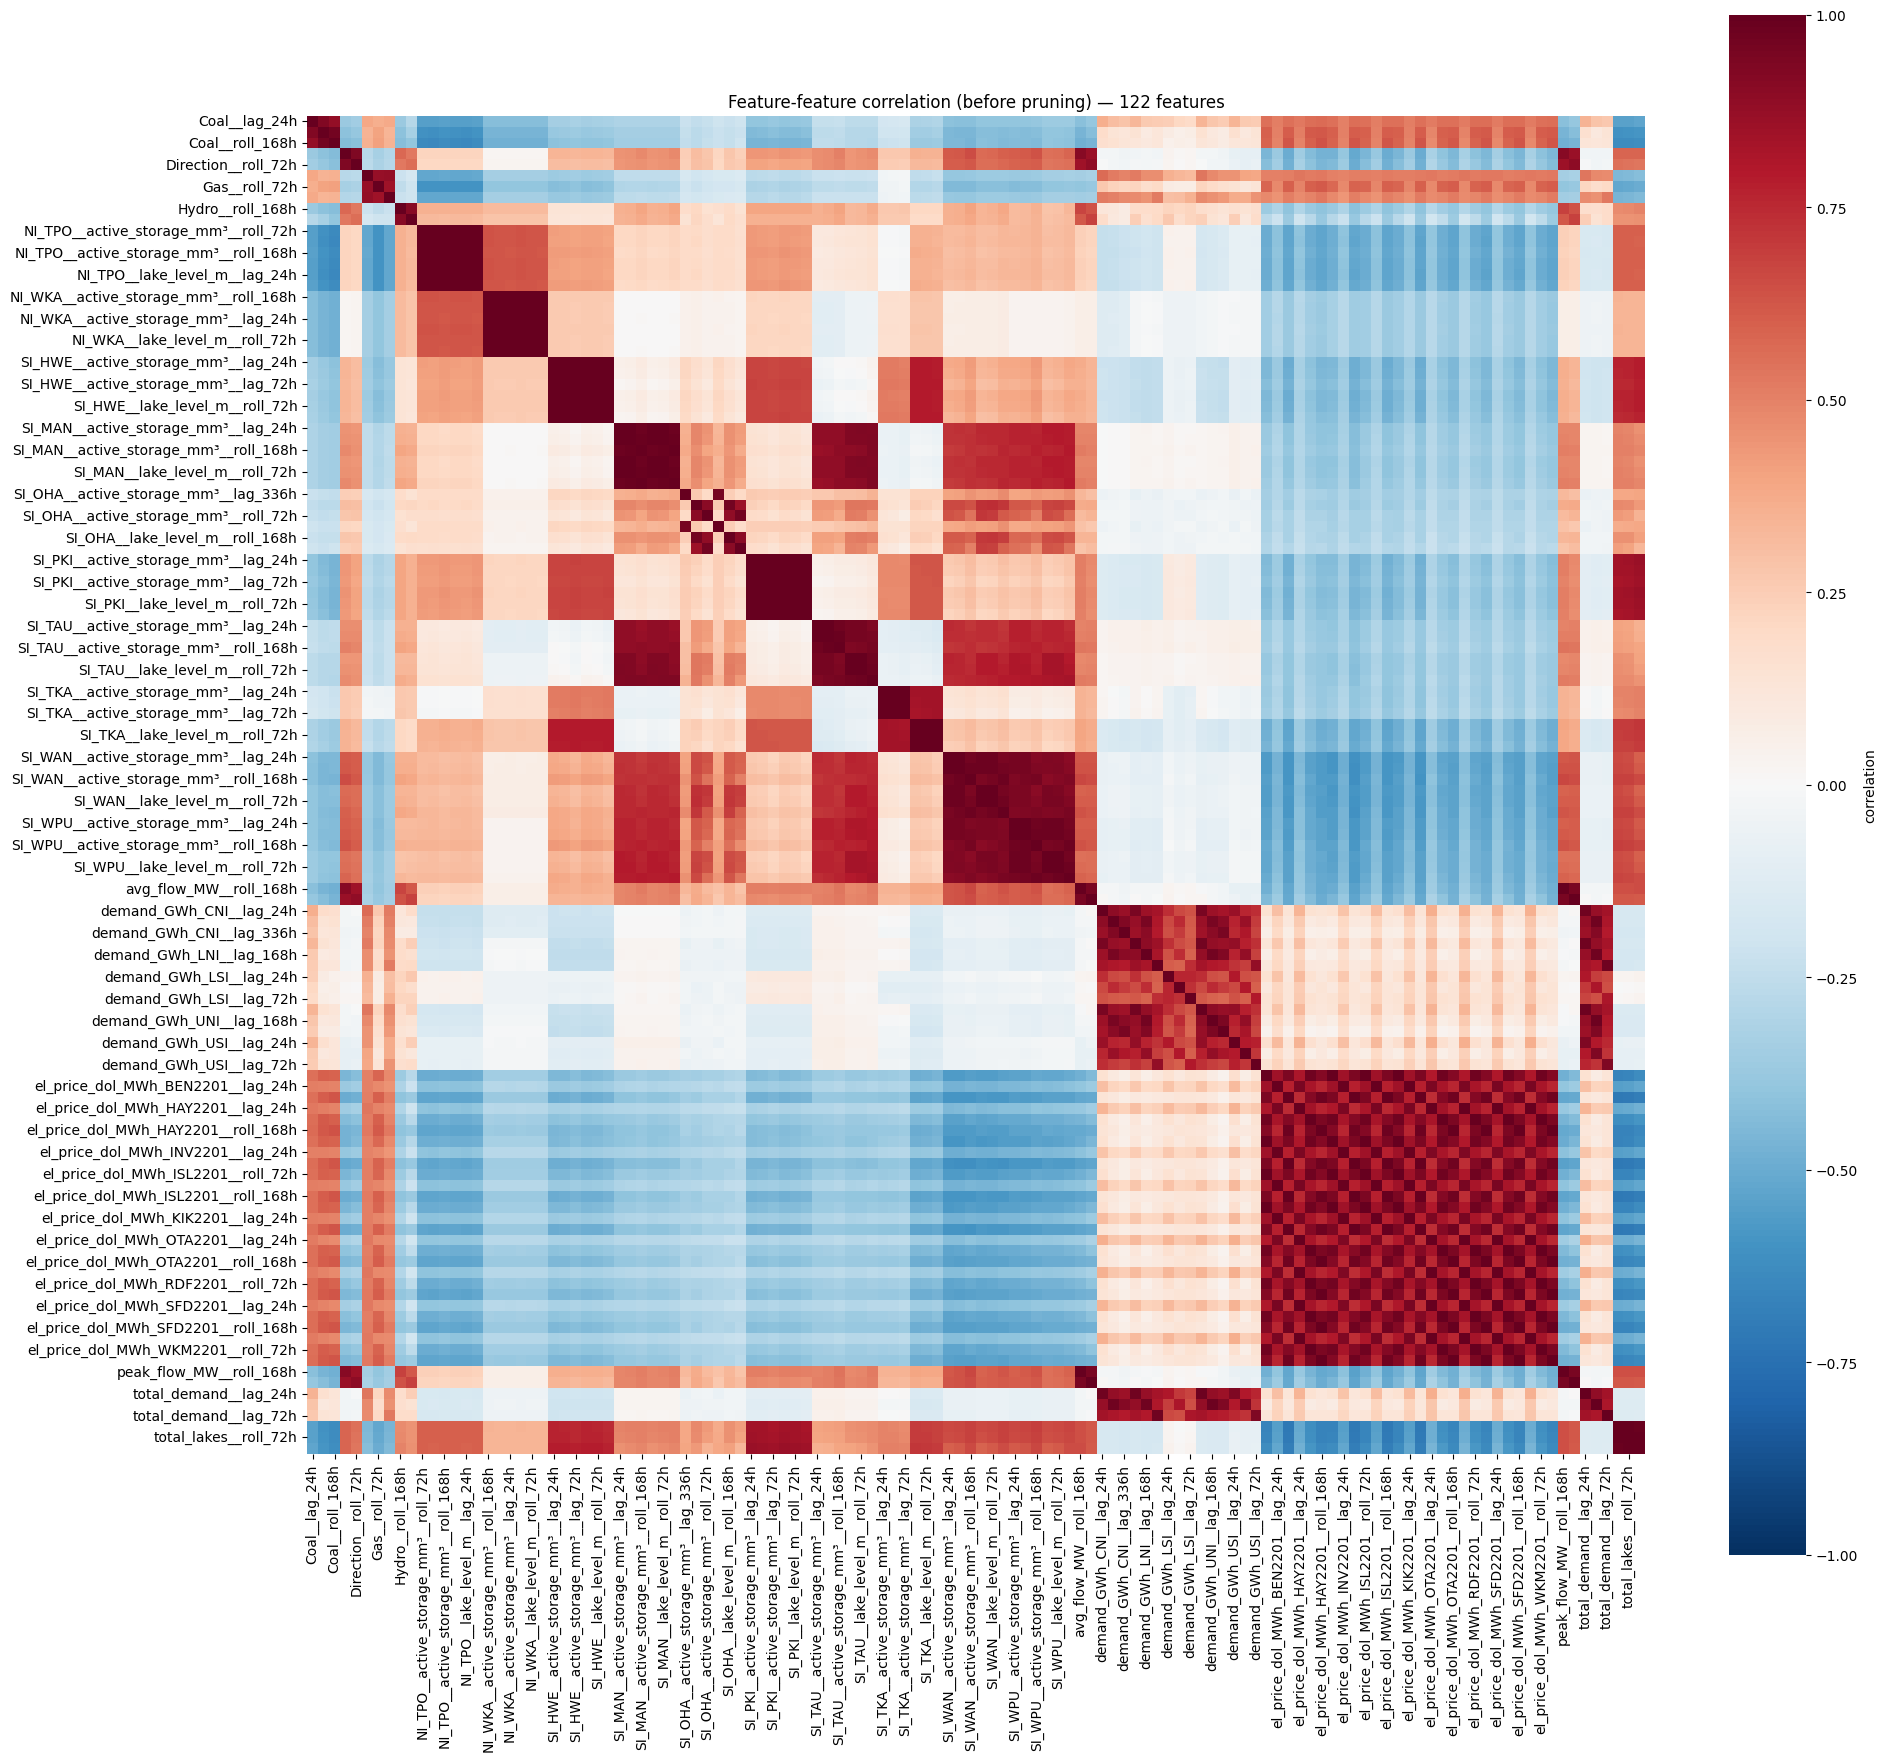

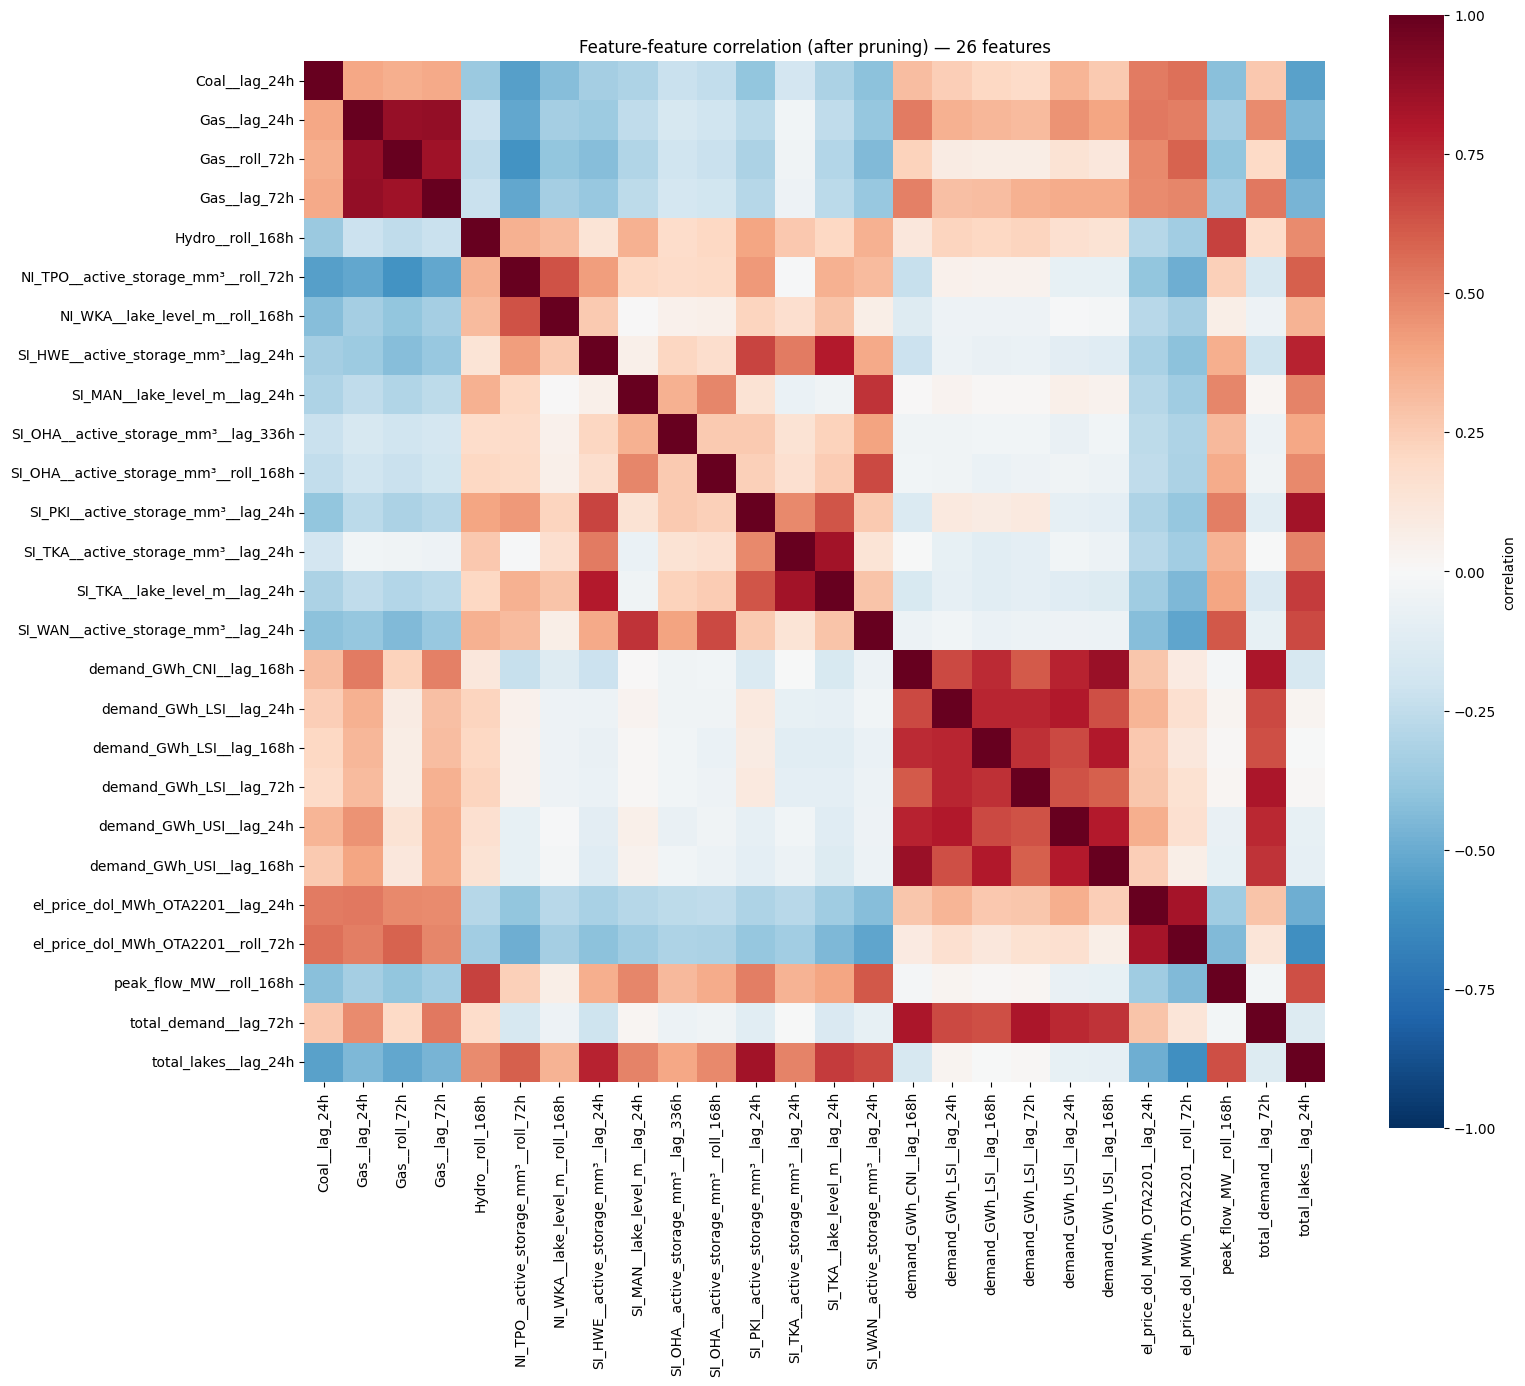

Shape: (50221, 27)
Columns: ['Coal__lag_24h', 'Gas__lag_24h', 'Gas__roll_72h', 'Gas__lag_72h', 'Hydro__roll_168h', 'NI_TPO__active_storage_mm³__roll_72h', 'NI_WKA__lake_level_m__roll_168h', 'SI_HWE__active_storage_mm³__lag_24h', 'SI_MAN__lake_level_m__lag_24h', 'SI_OHA__active_storage_mm³__lag_336h', 'SI_OHA__active_storage_mm³__roll_168h', 'SI_PKI__active_storage_mm³__lag_24h', 'SI_TKA__active_storage_mm³__lag_24h', 'SI_TKA__lake_level_m__lag_24h', 'SI_WAN__active_storage_mm³__lag_24h', 'demand_GWh_CNI__lag_168h', 'demand_GWh_LSI__lag_24h', 'demand_GWh_LSI__lag_168h', 'demand_GWh_LSI__lag_72h', 'demand_GWh_USI__lag_24h', 'demand_GWh_USI__lag_168h', 'el_price_dol_MWh_OTA2201__lag_24h', 'el_price_dol_MWh_OTA2201__roll_72h', 'peak_flow_MW__roll_168h', 'total_demand__lag_72h', 'total_lakes__lag_24h', 'el_price_dol_MWh_OTA2201']


In [5]:
# ── Load dataset ──────────────────────────────────────────────────────────────
# Single source containing both pre-processed features AND the target column.
# Lagging, rolling, ffill already done upstream — no preprocessing needed here.
#
# TODO: update path when the new dataset is ready

# data_path = '../../Data_Processing/preprocessed_features.csv'   # update this

# df = pd.read_csv(data_path)
# df["datetime_utc12"] = pd.to_datetime(df["datetime_utc12"])

target_col = "el_price_dol_MWh_OTA2201"

df = run_full_preprocessing(
    data_folder = "/home/jpelletier/Downloads/data",
    start_date = "2019-01-01",
    end_date = "2024-12-31"
)

df = prepare_xgboost_features(
    df = df,
    target = "el_price_dol_MWh_OTA2201",
    skew_threshold=0.9,
    target_corr_cutoff=0.20,
    top_n_lags=3,
    multicoll_threshold=0.9,
    verbose=True,
)

df = build_xgboost_dataset(df)


print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

In [ ]:
result.info()

In [6]:
# ── Minimal preprocessing ─────────────────────────────────────────────────────
# Lagging, rolling, ffill already done upstream.
# Steps here:
#   1. Sort by datetime
#   2. Add time features (raw + cyclical)
#   3. NaN check

df = df.sort_values("datetime_utc12").reset_index(drop=True)

# Raw time features
df["hour"]       = df["datetime_utc12"].dt.hour
df["dayofweek"]  = df["datetime_utc12"].dt.dayofweek
df["month"]      = df["datetime_utc12"].dt.month
df["dayofyear"]  = df["datetime_utc12"].dt.dayofyear
df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

# Cyclical encoding on top of raw
df["weekofyear"] = df["datetime_utc12"].dt.isocalendar().week.astype(int)

df["dow_sin"]   = np.sin(2 * np.pi * df["dayofweek"] / 7)
df["dow_cos"]   = np.cos(2 * np.pi * df["dayofweek"] / 7)
df["week_sin"]  = np.sin(2 * np.pi * df["weekofyear"] / 52)
df["week_cos"]  = np.cos(2 * np.pi * df["weekofyear"] / 52)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# Drop weekofyear raw integer — fully captured by week_sin/cos
# Keep hour, dayofweek, month, dayofyear, is_weekend as explicit features
df = df.drop(columns=["weekofyear"])

# NaN check
missing = df.isna().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    print("NaNs found — dropping affected rows:")
    print(missing)
    rows_before = len(df)
    df = df.dropna().reset_index(drop=True)
    print(f"Rows removed: {rows_before - len(df)}")
else:
    print("No NaNs — data is clean.")

print(f"\nFinal shape : {df.shape}")
print(f"Date range  : {df['datetime_utc12'].min().date()} → {df['datetime_utc12'].max().date()}")

KeyError: 'datetime_utc12'

In [ ]:
# ── Define X and y ────────────────────────────────────────────────────────────

exclude_cols = ["datetime_utc12", target_col]
feature_cols = [c for c in df.columns if c not in exclude_cols]

X = df[feature_cols]
y = df[target_col]

print("Feature matrix shape:", X.shape)
print("Number of features:  ", len(feature_cols))

In [ ]:
# ── Train/Test Split — 80/20 time-ordered ────────────────────────────────────

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print(f"Train: {X_train.shape}  {df['datetime_utc12'].iloc[0].date()} → {df['datetime_utc12'].iloc[split_index-1].date()}")
print(f"Test : {X_test.shape}   {df['datetime_utc12'].iloc[split_index].date()} → {df['datetime_utc12'].iloc[-1].date()}")

In [ ]:
# ── Optuna Hyperparameter Optimisation ───────────────────────────────────────
#
# Validation: 3 consecutive 3-month windows covering different NZ market regimes.
# Each window trains on all data before it (expanding, no leakage).
#
#   Summer : Jan–Mar 2022
#   Fall   : Apr–Jun 2022
#   Winter : Jul–Sep 2022

SEARCH_WINDOWS = [
    ("2022-01-01", "2022-04-01"),   # NZ summer  (3 months)
    ("2022-04-01", "2022-07-01"),   # NZ fall    (3 months)
    ("2022-07-01", "2022-10-01"),   # NZ winter  (3 months)
]

N_TRIALS = 50   # increase to 100 for more thorough search

# Build (train_idx, val_idx) pairs
train_dates = df["datetime_utc12"].iloc[:split_index].reset_index(drop=True)

custom_splits = []
for start_str, end_str in SEARCH_WINDOWS:
    start_ts = pd.Timestamp(start_str)
    end_ts   = pd.Timestamp(end_str)

    val_mask   = (train_dates >= start_ts) & (train_dates < end_ts)
    train_mask = train_dates < start_ts

    val_idx   = np.where(val_mask.values)[0]
    train_idx = np.where(train_mask.values)[0]

    if len(val_idx) == 0:
        print(f"WARNING: no data for {start_str} → {end_str} — check dates are in training set.")
    else:
        custom_splits.append((train_idx, val_idx))
        print(f"{start_str} → {end_str}:  train={len(train_idx):,} rows   val={len(val_idx):,} rows")

print(f"\n{len(custom_splits)} validation windows confirmed.\n")

# ── Optuna objective function ─────────────────────────────────────────────────

def objective(trial):
    params = {
        "learning_rate":    trial.suggest_float("learning_rate",    0.01, 0.3,  log=True),
        "subsample":        trial.suggest_float("subsample",        0.6,  1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6,  1.0),
        "reg_alpha":        trial.suggest_float("reg_alpha",        0.0,  10.0),
        "gamma":            trial.suggest_float("gamma",            0.0,  2.0),
        "n_estimators":     trial.suggest_int("n_estimators",      100,  500,  step=50),
        "max_depth":        trial.suggest_int("max_depth",         3,    8),
        "min_child_weight": trial.suggest_int("min_child_weight",  1,    10),
        "random_state": 42,
        "n_jobs": -1,
    }

    fold_maes = []
    for train_idx, val_idx in custom_splits:
        X_tr  = X_train.iloc[train_idx]
        y_tr  = y_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_val = y_train.iloc[val_idx]

        m = XGBRegressor(**params)
        m.fit(X_tr, y_tr)
        pred = np.clip(m.predict(X_val), 0, None)
        fold_maes.append(mean_absolute_error(y_val, pred))

    return np.mean(fold_maes)

# ── Run study ─────────────────────────────────────────────────────────────────
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

BEST_PARAMS = study.best_params
BEST_PARAMS["random_state"] = 42
BEST_PARAMS["n_jobs"]       = -1

print(f"Best mean MAE across 3 windows : {study.best_value:.4f}")
print("\nBest parameters:")
for k, v in sorted(BEST_PARAMS.items()):
    if k not in ["random_state", "n_jobs"]:
        print(f"  {k:<22}: {v}")

In [ ]:
# ── Optuna visualisation ──────────────────────────────────────────────────────
# Requires: pip install plotly
#
# Plot 1 — Optimization history: MAE per trial + running best
#   Shows how quickly Optuna converges. A flat line early = good sampler.
#
# Plot 2 — Parameter importance: which params mattered most for MAE
#   Computed via fANOVA — quantifies how much variance in MAE each param explains.
#   Use this to decide which params to widen/narrow in future searches.

try:
    from optuna.visualization import plot_optimization_history, plot_param_importances

    fig1 = plot_optimization_history(study)
    fig1.update_layout(title="Optuna: MAE per trial (lower = better)")
    fig1.show()

    fig2 = plot_param_importances(study)
    fig2.update_layout(title="Optuna: Parameter importance for MAE")
    fig2.show()

except ImportError:
    print("plotly not installed — run:  pip install plotly")
    print("Falling back to text summary:")
    print(f"\nBest trial : #{study.best_trial.number}")
    print(f"Best MAE   : {study.best_value:.4f}")
    trials_df = study.trials_dataframe()
    print(f"\nTop 5 trials:")
    print(trials_df.sort_values("value").head(5)[["number","value"] +
          [c for c in trials_df.columns if c.startswith("params_")]].to_string(index=False))

In [ ]:
# ── 12-Fold Expanding-Window CV ───────────────────────────────────────────────
# Uses best params from random search.
# test_size=720 ≈ 1 month → 12 folds covers full 2024

tscv = TimeSeriesSplit(n_splits=12, test_size=720)

fold_results = []

print(f"{'Fold':>4}  {'Month':>10}  {'MAE model':>10}  {'MAE naive':>10}  {'RMSE model':>11}  {'RMSE naive':>11}  {'MASE':>6}")
print("-" * 72)

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):

    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    # XGBoost with best params
    m = XGBRegressor(**BEST_PARAMS)
    m.fit(X_tr, y_tr)
    y_model = np.clip(m.predict(X_te), 0, None)

    # Naive: yesterday same hour
    # Update column name if your feature file uses a different lag column name
    naive_col = "target_lag_24h" if "target_lag_24h" in X_te.columns else X_te.columns[0]
    y_naive = X_te[naive_col].values

    mae_m  = mean_absolute_error(y_te, y_model)
    mae_n  = mean_absolute_error(y_te, y_naive)
    rmse_m = np.sqrt(mean_squared_error(y_te, y_model))
    rmse_n = np.sqrt(mean_squared_error(y_te, y_naive))
    mase   = mae_m / mae_n

    timestamps  = df["datetime_utc12"].iloc[test_idx].values
    month_label = pd.Timestamp(timestamps[0]).strftime("%b %Y")

    fold_results.append({
        "fold":       fold,
        "month":      month_label,
        "timestamps": timestamps,
        "y_actual":   y_te.values,
        "y_model":    y_model,
        "y_naive":    y_naive,
        "mae_model":  mae_m,
        "mae_naive":  mae_n,
        "rmse_model": rmse_m,
        "rmse_naive": rmse_n,
        "mase":       mase,
    })

    print(f"{fold:>4}  {month_label:>10}  {mae_m:>10.2f}  {mae_n:>10.2f}  "
          f"{rmse_m:>11.2f}  {rmse_n:>11.2f}  {mase:>6.3f}")

In [ ]:
# ── Summary Table ─────────────────────────────────────────────────────────────

summary = pd.DataFrame([{
    "Month":       r["month"],
    "MAE model":   r["mae_model"],
    "MAE naive":   r["mae_naive"],
    "RMSE model":  r["rmse_model"],
    "RMSE naive":  r["rmse_naive"],
    "MASE":        r["mase"],
    "Beats naive": "✓" if r["mase"] < 1 else "✗"
} for r in fold_results])

avg_row = pd.DataFrame([{
    "Month":       "AVERAGE",
    "MAE model":   summary["MAE model"].mean(),
    "MAE naive":   summary["MAE naive"].mean(),
    "RMSE model":  summary["RMSE model"].mean(),
    "RMSE naive":  summary["RMSE naive"].mean(),
    "MASE":        summary["MASE"].mean(),
    "Beats naive": f"{(summary['MASE'] < 1).sum()} / 12"
}])

pd.set_option("display.float_format", "{:.2f}".format)
print(pd.concat([summary, avg_row], ignore_index=True).to_string(index=False))

In [ ]:
# ── Monthly Visualisation — Best & Worst Week per Fold ────────────────────────

def find_best_worst_weeks(y_actual, y_model, week_size=168):
    n_weeks = len(y_actual) // week_size
    week_maes = []
    for w in range(n_weeks):
        s, e = w * week_size, (w + 1) * week_size
        week_maes.append((mean_absolute_error(y_actual[s:e], y_model[s:e]), s, e))
    return min(week_maes, key=lambda x: x[0]), max(week_maes, key=lambda x: x[0])


for r in fold_results:
    best, worst = find_best_worst_weeks(r["y_actual"], r["y_model"])

    fig, axes = plt.subplots(2, 1, figsize=(16, 9))
    fig.suptitle(
        f"{r['month']}  —  MAE model: {r['mae_model']:.1f}  "
        f"naive: {r['mae_naive']:.1f}  MASE: {r['mase']:.3f}",
        fontsize=12
    )

    for ax, (mae, s, e), label in zip(
        axes,
        [best, worst],
        ["Best week (lowest MAE)", "Worst week (highest MAE)"]
    ):
        ts  = r["timestamps"][s:e]
        act = r["y_actual"][s:e]
        mod = r["y_model"][s:e]
        nav = r["y_naive"][s:e]

        ax.plot(ts, act, label="Actual",  color="steelblue",  linewidth=1.5)
        ax.plot(ts, mod, label="XGBoost", color="darkorange", linewidth=1.5, linestyle="--")
        ax.plot(ts, nav, label="Naive",   color="gray",       linewidth=1.0, linestyle=":")
        ax.set_title(f"{label}  —  MAE: {mae:.1f} NZD/MWh")
        ax.set_ylabel("Price (NZD/MWh)")
        ax.set_ylim(bottom=0)
        ax.legend(fontsize=8, loc="upper right")
        ax.tick_params(axis="x", labelrotation=30)

    plt.tight_layout()
    plt.show()

In [ ]:
# ── Final Model — trained on 80% with best params ────────────────────────────

xgb_model = XGBRegressor(**BEST_PARAMS)
xgb_model.fit(X_train, y_train)

y_pred = np.clip(xgb_model.predict(X_test), 0, None)

mae_f  = mean_absolute_error(y_test, y_pred)
rmse_f = np.sqrt(mean_squared_error(y_test, y_pred))
r2_f   = r2_score(y_test, y_pred)

print("Final model — best params from random search")
print(f"  MAE  : {mae_f:.4f}")
print(f"  RMSE : {rmse_f:.4f}")
print(f"  R²   : {r2_f:.4f}")
print(f"\nBest params used:")
for k, v in sorted(BEST_PARAMS.items()):
    if k not in ["random_state", "n_jobs"]:
        print(f"  {k:<22}: {v}")

In [ ]:
# ── Feature Importance ────────────────────────────────────────────────────────

importance_df = pd.DataFrame({
    "feature":    X_train.columns,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

print(importance_df.head(20).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top20 = importance_df.head(20)
axes[0].barh(top20["feature"][::-1], top20["importance"][::-1])
axes[0].set_title("Top 20 Feature Importances")
axes[0].set_xlabel("Importance")

axes[1].bar(range(len(importance_df)), importance_df["importance"].values)
axes[1].set_title("Importance Distribution — All Features")
axes[1].set_xlabel("Feature rank")
axes[1].set_ylabel("Importance")

plt.tight_layout()
plt.show()

In [ ]:
# ── Seasonal 14-Day Forecasts ─────────────────────────────────────────────────
# Update naive_col if your feature file uses a different column name

naive_col = "target_lag_24h"   # yesterday same hour — update if needed

def rolling_forecast(model, start_date, n_days=14):
    start_ts = pd.Timestamp(start_date)
    mask = (
        (df["datetime_utc12"] >= start_ts) &
        (df["datetime_utc12"] <  start_ts + pd.Timedelta(hours=n_days * 24))
    )
    d = df[mask].reset_index(drop=True)
    if len(d) < n_days * 24:
        raise ValueError(f"Not enough data from {start_date}")
    preds = np.clip(model.predict(d[feature_cols].values), 0, None)
    naive = d[naive_col].values if naive_col in d.columns else np.full(len(d), np.nan)
    return preds, d[target_col].values, d["datetime_utc12"].values, naive


seasons = {
    "Summer — 8 Jan 2024":  "2024-01-08",
    "Autumn — 1 Apr 2024":  "2024-04-01",
    "Winter — 1 Jul 2024":  "2024-07-01",
    "Spring — 1 Oct 2024":  "2024-10-01",
}

fig, axes = plt.subplots(4, 1, figsize=(16, 22))
fig.suptitle("14-Day Seasonal Forecast — OTA2201 (NZD/MWh)", fontsize=13, y=1.01)

for ax, (label, start) in zip(axes, seasons.items()):
    preds, actuals, ts, naive = rolling_forecast(xgb_model, start)
    mae_m = mean_absolute_error(actuals, preds)
    mae_n = mean_absolute_error(actuals, naive) if not np.isnan(naive).all() else float('nan')

    ax.plot(ts, actuals, label="Actual",  color="steelblue",  linewidth=1.5)
    ax.plot(ts, preds,   label="XGBoost", color="darkorange", linewidth=1.5, linestyle="--")
    if not np.isnan(naive).all():
        ax.plot(ts, naive, label="Naive", color="gray",       linewidth=1.0, linestyle=":")
    ax.set_title(f"{label}  —  MAE model: {mae_m:.1f}  naive: {mae_n:.1f}")
    ax.set_ylabel("Price (NZD/MWh)")
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=8, loc="upper right")
    ax.tick_params(axis="x", labelrotation=30)

plt.tight_layout()
plt.show()

In [ ]:
# ── Save model ────────────────────────────────────────────────────────────────
# Saves the final trained model + best hyperparameters + feature list.
# All three files share the same timestamp-based name for traceability.
#
# Files saved:
#   .ubj  — XGBoost native binary format (fast, portable, version-safe)
#   .json — best hyperparameters from random search
#   .txt  — ordered list of feature columns (needed to reconstruct X at inference)

import json
from datetime import datetime

# Clear, distinct model name: model type + target node + timestamp
timestamp  = datetime.now().strftime("%Y%m%d_%H%M")
model_name = f"xgb_v4_OTA2201_{timestamp}"
save_dir   = "./"   # update to preferred save directory

# 1. Model weights (XGBoost native format)
model_path = f"{save_dir}{model_name}.ubj"
xgb_model.save_model(model_path)

# 2. Best hyperparameters
params_to_save = {k: v for k, v in BEST_PARAMS.items()
                  if k not in ["random_state", "n_jobs"]}
params_path = f"{save_dir}{model_name}_params.json"
with open(params_path, "w") as f:
    json.dump(params_to_save, f, indent=2)

# 3. Feature column list (order matters for inference)
features_path_out = f"{save_dir}{model_name}_features.txt"
with open(features_path_out, "w") as f:
    f.write("\n".join(feature_cols))

print(f"Model saved as : {model_name}")
print(f"  Weights      : {model_path}")
print(f"  Params       : {params_path}")
print(f"  Features     : {features_path_out}")
print(f"\nTo reload:")
print(f"  model = XGBRegressor()")
print(f"  model.load_model('{model_path}')")